In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("/content/github_projects.csv")
df['creation'] = pd.to_datetime(df['creation'])
df['updating'] = pd.to_datetime(df['updating'])

In [3]:
CTTM = df.groupby(df['creation'].dt.year).size()

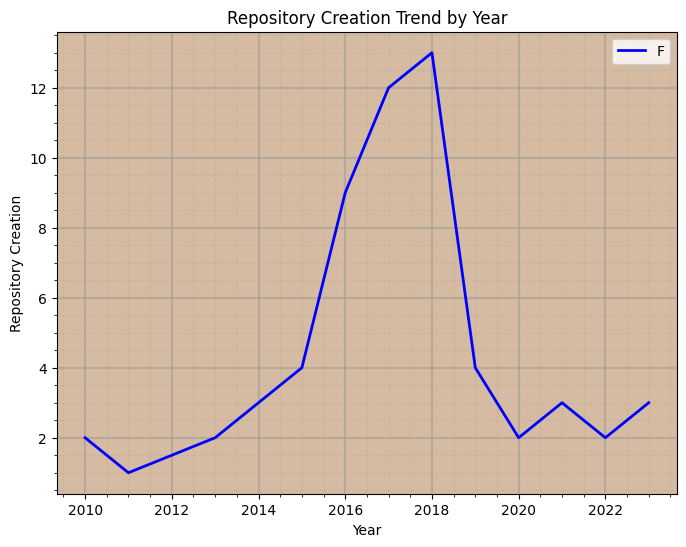

In [4]:
plt.figure(figsize=(8, 6), facecolor='white')
ax = plt.gca()
ax.set_facecolor('#D4BBA1')
Lineplot1=plt.plot(CTTM,color="blue",linewidth=2,linestyle='-')
plt.xlabel("Year")
plt.ylabel("Repository Creation")
plt.title("Repository Creation Trend by Year")
plt.minorticks_on()
plt.grid(visible=True, which='major', color='#999999', linestyle='-', linewidth=1.5, alpha=0.5)
plt.grid(visible=True, which='minor', color='#999999', linestyle='--', linewidth=0.8, alpha=0.2)
plt.legend("Frequency")
plt.savefig('Lineplot.png')
plt.show()


In [5]:
Lan=df.groupby(by="language").size()
Lic=df.groupby(by="license").size()
Lic=Lic.sort_values(ascending=False)
Lan=Lan.sort_values(ascending=False)
neon_colors1 = [
    "#39FF14",
    "#FFF01F",
    "#1F51FF",
    "#FF007F",
    "#FF5E00",
    "#BF00FF",
    "#FF3131",
    "#0FF0FC",
    "#7EEE15",
    "#F000FF"
]
neon_colors2 = [
    "#39FF14",
    "#FFF01F",
    "#1F51FF",
    "#FF007F",
    "#FF5E00",
    "#BF00FF",
    "#FF3131",
    "#0FF0FC",
    "#7EEE15",
    "#F000FF",
    "#FF00AA",
    "#00FFD2"
]

explode1=[0.05] + [0] * (len(Lan.index.to_list())-1)
explode2=[0.05] + [0] * (len(Lic.index.to_list())-1)

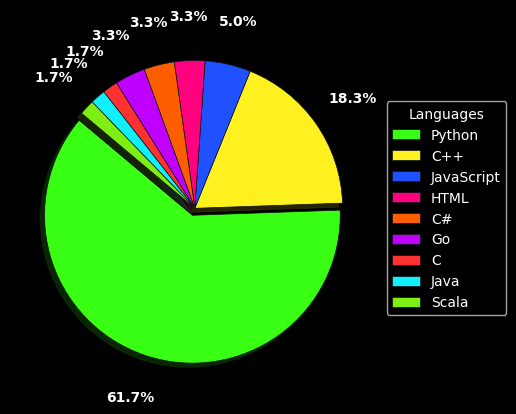

In [6]:
plt.style.use("dark_background")

wedges, texts, autotexts = plt.pie(
    Lan.values,
    labels=None,
    explode=explode1,
    autopct="%1.1f%%",
    colors=neon_colors1[:len(Lan)],
    shadow=True,
    startangle=140,
    pctdistance=1.3,
    textprops=dict(color="white", fontsize=10, weight="bold"),
    wedgeprops=dict(edgecolor="#0e1013", linewidth=0.5)
)

plt.legend(
    wedges,
    Lan.index.tolist(),
    title="Languages",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

plt.savefig("PieChart1.png")
plt.show()

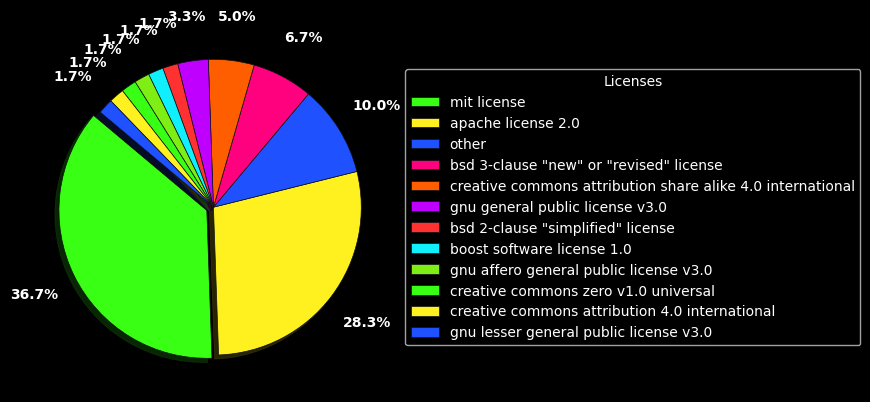

In [7]:
plt.style.use("dark_background")

wedges, texts, autotexts = plt.pie(
    Lic.values,
    labels=None,
    explode=explode2,
    autopct="%1.1f%%",
    colors=neon_colors2[:len(Lan)],
    shadow=True,
    startangle=140,
    pctdistance=1.3,
    textprops=dict(color="white", fontsize=10, weight="bold"),
    wedgeprops=dict(edgecolor="#0e1013", linewidth=0.5)
)
plt.legend(
    wedges,
    Lic.index.tolist(),
    title="Licenses",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

plt.savefig("PieChart2.png")
plt.show()

In [8]:
stars = df.sort_values(by="stargazers", ascending=False).head(10)
Lstars = df.sort_values(by="stargazers", ascending=False).tail(10)
Fai = df.sort_values(by="open_issues", ascending=True).tail(10)
LFai = df.sort_values(by="open_issues", ascending=True).head(10)

In [9]:
Worst = df[df["owner"].isin(Lstars["owner"]) & df["owner"].isin(Fai["owner"])][["language","owner"]]
Best    = df[df["owner"].isin(stars["owner"]) & df["owner"].isin(LFai["owner"])][["language","owner"]]
Veryg  = df[df["owner"].isin(stars["owner"])][["language","owner"]]
Bad=df[df["owner"].isin(Lstars["owner"]) ][["language","owner"]]
Best=Best.drop_duplicates()
Veryg=Veryg.drop_duplicates()
Bad=Bad.drop_duplicates()
Worst=Worst.drop_duplicates()

print("=== Owners Classification Report ===")
print("\n[Best Owners]:")
print(Best)

print("\n[Very Good Owners]:")
print(Veryg)

print("\n[Bad Owners]:")
print(Bad)

print("\n[Worst Owners]:")
print(Worst)

=== Owners Classification Report ===

[Best Owners]:
  language      owner
2   Python  microsoft

[Very Good Owners]:
      language            owner
0          C++       tensorflow
1       Python      huggingface
2       Python        microsoft
3       Python   fighting41love
4       Python     josephmisiti
5       Python     scikit-learn
6       Python       gradio-app
7          C++    thealgorithms
8   JavaScript       lutzroeder
9       Python  eriklindernoren
15           C    thealgorithms
26  JavaScript      huggingface

[Bad Owners]:
   language         owner
50     HTML     chiphuyen
51   Python  jack-cherish
52   Python    roboticcam
53   Python  epistasislab
54   Python        sktime
55   Python   huseinzol05
56       Go     replicate
57       Go   sjwhitworth
58       C#        dotnet
59      C++      catboost

[Worst Owners]:
   language     owner
54   Python    sktime
58       C#    dotnet
59      C++  catboost


# **P_Languages of Best Owners**

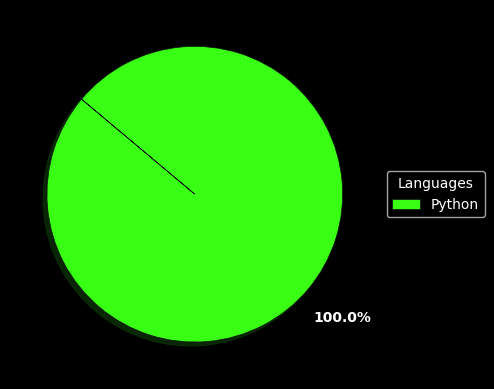

In [10]:


plt.style.use("dark_background")

language_counts1 = Best["language"].value_counts()
language_names1 = language_counts1.index.tolist()

wedges, texts, autotexts = plt.pie(
    language_counts1,
    autopct="%1.1f%%",
    colors=neon_colors1[:len(language_counts1)],
    shadow=True,
    startangle=140,
    pctdistance=1.3,
    textprops=dict(color="white", fontsize=10, weight="bold"),
    wedgeprops=dict(edgecolor="#0e1013", linewidth=0.5)
)

plt.legend(
    wedges,
    language_names1,
    title="Languages",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

plt.savefig("PieChart3.png")
plt.show()

# **P_Languages of Very_Good Owners**

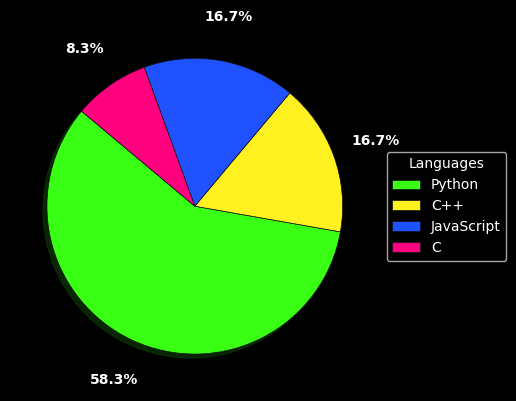

In [11]:

plt.style.use("dark_background")

language_counts2 = Veryg["language"].value_counts()
language_names2 = language_counts2.index.tolist()

wedges, texts, autotexts = plt.pie(
    language_counts2,
    autopct="%1.1f%%",
    colors=neon_colors1[:len(language_counts2)],
    shadow=True,
    startangle=140,
    pctdistance=1.3,
    textprops=dict(color="white", fontsize=10, weight="bold"),
    wedgeprops=dict(edgecolor="#0e1013", linewidth=0.5)
)

plt.legend(
    wedges,
    language_names2,
    title="Languages",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

plt.savefig("PieChart4.png")
plt.show()

# **P_Languages of Bad Owners**

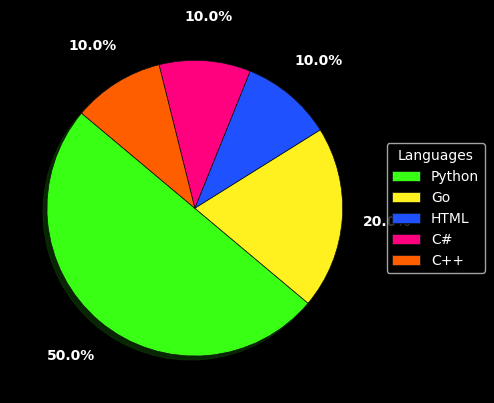

In [12]:

plt.style.use("dark_background")

language_counts3 = Bad["language"].value_counts()
language_names3 = language_counts3.index.tolist()

wedges, texts, autotexts = plt.pie(
    language_counts3,
    autopct="%1.1f%%",
    colors=neon_colors1[:len(language_counts3)],
    shadow=True,
    startangle=140,
    pctdistance=1.3,
    textprops=dict(color="white", fontsize=10, weight="bold"),
    wedgeprops=dict(edgecolor="#0e1013", linewidth=0.5)
)

plt.legend(
    wedges,
    language_names3,
    title="Languages",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

plt.savefig("PieChart5.png")
plt.show()

# **P_Languages of Worst Owners**

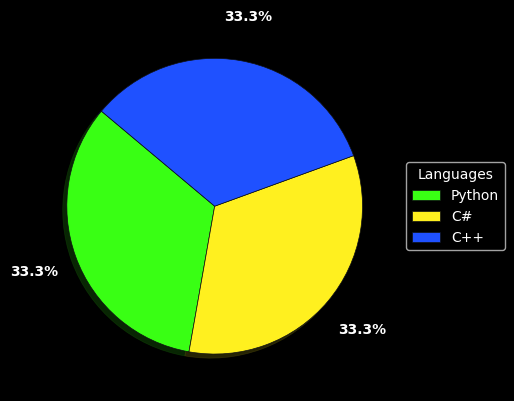

In [13]:

plt.style.use("dark_background")

language_counts4 = Worst["language"].value_counts()
language_names4 = language_counts4.index.tolist()

wedges, texts, autotexts = plt.pie(
    language_counts4,
    autopct="%1.1f%%",
    colors=neon_colors1[:len(language_counts4)],
    shadow=True,
    startangle=140,
    pctdistance=1.3,
    textprops=dict(color="white", fontsize=10, weight="bold"),
    wedgeprops=dict(edgecolor="#0e1013", linewidth=0.5)
)

plt.legend(
    wedges,
    language_names4,
    title="Languages",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

plt.savefig("PieChart6.png")
plt.show()

**Last but not least, we have reached the third and final part of this notebook, which was split into three sections to optimize Google Colab's memory usage.1. Line Chart AnalysisBased on the line chart, 2018 recorded the highest number of repository submissions, while 2011 was the lowest. For the remaining years, the numbers fluctuate around an average of 3 repositories (either increasing to 4 or decreasing to 2). Notably, the years 2016, 2017, and 2018 significantly exceeded the 4-repository threshold; 2016 saw 8 submissions, 2017 had 12, and 2018 peaked with 13 repositories.2. Pie Chart AnalysisFirst Pie Chart: Highlights the most common programming languages. The top three widely used languages are Python, C++, and JavaScript.Second Pie Chart: Displays the popular software licenses used by repository owners, with MIT and Apache licenses being the most dominant.Telescope Accuracy Tiers Analysis (Sub-Pie Charts):Prior to plotting, a statistical calculation was performed to determine if the programming language impacts telescope accuracy. We categorized the groups into four tiers: Best, Very Good, Bad, and Worst. To improve readability, we created sub-charts for each group:The "Best" Group: Consists of only one owner (Microsoft) using Python.The "Very Good" Group: Includes 10 owners, where Python remains the dominant language, followed by C++ at 16.7%.The "Worst" Group: Displays a wider diversity of programming languages among owners; Python takes the lead at 50%, followed by Go at 20%, while HTML, C#, and C++ evenly share the remaining distribution at 10% each.The "Bad" Group: The distribution is split completely equal at 33.3% each among three languages: Python, C#, and C++.ConclusionAfter processing and cross-analyzing all the data across all tiers, we concluded that the programming language does not influence the telescope's observation accuracy. Instead, accuracy depends entirely on the technical design and engineering architecture of the telescope, alongside the skill and expertise of the operator using it.**